* Author: Patrick Earl
* Course: CSC223

## Introduction

This will focus on flights leaving NYC airports in 2013.

Source: <https://github.com/tidyverse/nycflights13>

## Data Prep

This is just import statements and importing the data

In [4]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
dtypes = {
    'year': str,
    'month': str,
    'day': str,
    'hour': str,
    'minute': str
}

flights = pd.read_csv('./flight_data/nyc_flights.csv', dtype=dtypes)

flights.head()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01T10:00:00Z
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01T10:00:00Z
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01T10:00:00Z
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01T10:00:00Z
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01T11:00:00Z


In [6]:
weather = pd.read_csv('./flight_data/nyc_weather.csv')

weather.head()

,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,time_hour
0,EWR,2013,1,1,1,39.02,26.06,59.37,270.0,10.35702,NaN,0.0,1012.0,10.0,2013-01-01T06:00:00Z
1,EWR,2013,1,1,2,39.02,26.96,61.63,250.0,8.05546,NaN,0.0,1012.3,10.0,2013-01-01T07:00:00Z
2,EWR,2013,1,1,3,39.02,28.04,64.43,240.0,11.50780,NaN,0.0,1012.5,10.0,2013-01-01T08:00:00Z
3,EWR,2013,1,1,4,39.92,28.04,62.21,250.0,12.65858,NaN,0.0,1012.2,10.0,2013-01-01T09:00:00Z
4,EWR,2013,1,1,5,39.02,28.04,64.43,260.0,12.65858,NaN,0.0,1011.9,10.0,2013-01-01T10:00:00Z


In [7]:
flights = pd.merge(flights, weather, on=['origin', 'time_hour'], suffixes=(None, '_right'))

In [8]:
#2013/1/1 5:15
flights['datetime'] = pd.to_datetime(
    flights['year'] + '/' + 
    flights['month'] + '/' + 
    flights['day'] + ' ' +
    flights['hour'] + ':' +
    flights['minute']
)


In [9]:
# taking the flights dataset and making it a time series dataframe, using the datetime column
time_index = flights.set_index('datetime')
time_index = time_index.drop(['year', 'month', 'day', 'hour'], axis=1)

time_index.head()

,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,...,hour_right,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib
datetime,,,,,,,,,,,,,,,,,,,,,
2013-01-01 05:15:00,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,...,5,39.02,28.04,64.43,260.0,12.65858,NaN,0.0,1011.9,10.0
2013-01-01 05:58:00,554.0,558,-4.0,740.0,728,12.0,UA,1696,N39463,EWR,...,5,39.02,28.04,64.43,260.0,12.65858,NaN,0.0,1011.9,10.0
2013-01-01 05:29:00,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,...,5,39.92,24.98,54.81,250.0,14.96014,21.86482,0.0,1011.4,10.0
2013-01-01 05:40:00,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,...,5,39.02,26.96,61.63,260.0,14.96014,NaN,0.0,1012.1,10.0
2013-01-01 05:45:00,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,...,5,39.02,26.96,61.63,260.0,14.96014,NaN,0.0,1012.1,10.0


## Daily Flights leaving 3 NYC Airports for 2013

This will count number of flights on a daily basis leaving NYC

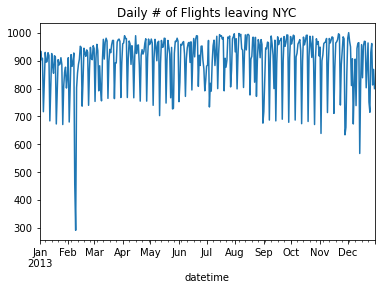

In [10]:
daily_count = time_index['dep_time'].resample('D').count()

daily_count.plot()
plt.title("Daily # of Flights leaving NYC");

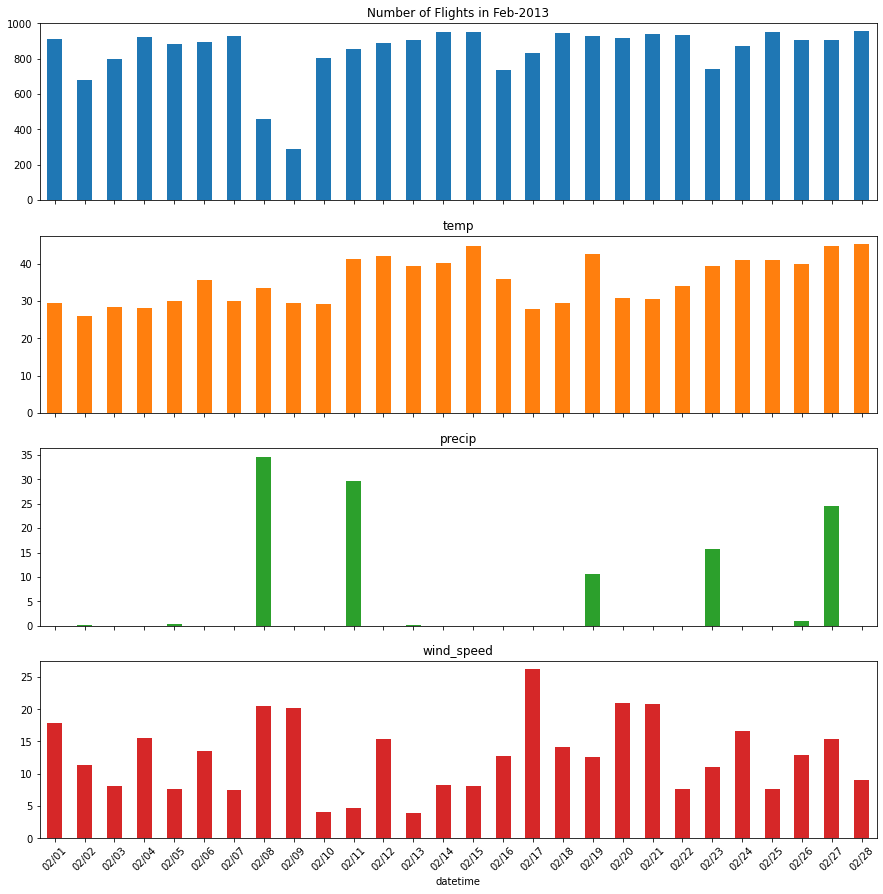

In [11]:
feb = time_index.loc['2013-02'][['dep_delay', 'temp', 'precip', 'wind_speed']].resample('D').agg({
    'dep_delay': 'count',
    'temp': 'mean',
    'precip': 'sum',
    'wind_speed': 'mean'
})

ax = feb.plot(kind='bar', subplots=True, layout=(4,1), legend=False, figsize=(15, 15))
ax[0,0].set_title('Number of Flights in Feb-2013');
# Set the ticklabel based on the DatetimeIndex. Use the "strftime" function on each Index and rotate by 45 degrees
# Bar charts axises start at 0, so mdates sees .
ax[3,0].set_xticklabels([x.strftime('%m/%d') for x in feb.index], rotation=45);